In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# First, let's read in the dataset and chec out its properties
df = pd.read_csv('HepatitisCdata.csv')
df.head()

,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [4]:
df.shape

(615, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    object 
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    object 
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB


In [6]:
df['Sex'].unique()

array(['m', 'f'], dtype=object)

In [7]:
# Parse strings to int for sex attribute
df['Sex'] = df['Sex'].map({'m': 1, 'f': 0})
df.head()

,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [8]:
df['Category'].unique()

array(['0=Blood Donor', '0s=suspect Blood Donor', '1=Hepatitis',
       '2=Fibrosis', '3=Cirrhosis'], dtype=object)

In [9]:
# Parse strings to int for category attribute
df.rename(columns={'Unnamed: 0': 'id'}, inplace=True)

category = {
    '0=Blood Donor': 0,
    '0s=suspect Blood Donor': 0,
    '1=Hepatitis': 1,
    '2=Fibrosis': 2,
    '3=Cirrhosis': 3
}

df['Category'] = df['Category'].map(category)
df.head()

,id,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [10]:
duplicated_ids = df["id"].isna().sum()
assert duplicated_ids == 0, "there are duplicated ids"

In [11]:
# find missing values
df.isna().sum()

id           0
Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
GGT          0
PROT         1
dtype: int64

In [12]:
# use median interpolation to fill missing values
df['ALB'] = df['ALB'].fillna(df['ALB'].median())
df['ALP'] = df['ALP'].fillna(df['ALP'].median())
df['ALT'] = df['ALT'].fillna(df['ALT'].median())
df['CHOL'] = df['CHOL'].fillna(df['CHOL'].median())
df['PROT'] = df['PROT'].fillna(df['PROT'].median())

df.isna().sum()


id          0
Category    0
Age         0
Sex         0
ALB         0
ALP         0
ALT         0
AST         0
BIL         0
CHE         0
CHOL        0
CREA        0
GGT         0
PROT        0
dtype: int64

In [13]:
df.describe()

,id,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
count,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000
mean,308.000000,0.253659,47.408130,0.613008,41.620732,68.222927,28.441951,34.786341,11.396748,8.196634,5.366992,81.287805,39.533171,72.044390
std,177.679487,0.742420,10.055105,0.487458,5.775935,25.646364,25.449889,33.090690,19.673150,2.205657,1.123499,49.756166,54.661071,5.398238
min,1.000000,0.000000,19.000000,0.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000,44.800000
25%,154.500000,0.000000,39.000000,0.000000,38.800000,52.950000,16.400000,21.600000,5.300000,6.935000,4.620000,67.000000,15.700000,69.300000
50%,308.000000,0.000000,47.000000,1.000000,41.950000,66.200000,23.000000,25.900000,7.300000,8.260000,5.300000,77.000000,23.300000,72.200000
75%,461.500000,0.000000,54.000000,1.000000,45.200000,79.300000,33.050000,32.900000,11.200000,9.590000,6.055000,88.000000,40.200000,75.400000
max,615.000000,3.000000,77.000000,1.000000,82.200000,416.600000,325.300000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000


In [14]:
df["Category"].value_counts()

0    540
3     30
1     24
2     21
Name: Category, dtype: int64

In [15]:
df["Sex"].value_counts()

1    377
0    238
Name: Sex, dtype: int64

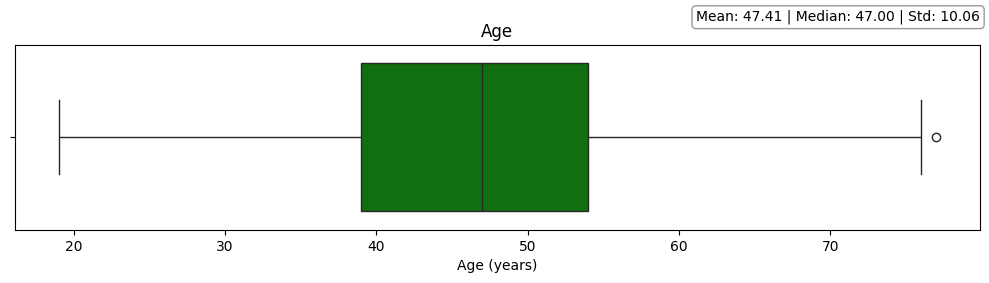

In [16]:
# To start exploring our data, we can make a Box-and-whisker plot for Age with summary statistics
plt.figure(figsize=(10, 3))
ax = sns.boxplot(x=df["Age"], color="green")

age_mean = df["Age"].mean()
age_median = df["Age"].median()
age_std = df["Age"].std()
summary = f"Mean: {age_mean:.2f} | Median: {age_median:.2f} | Std: {age_std:.2f}"

ax.set_title("Age")
ax.set_xlabel("Age (years)")
ax.text(1, 1.15, summary, transform=ax.transAxes, ha="right", va="center", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="gray"))

plt.tight_layout()
plt.show()


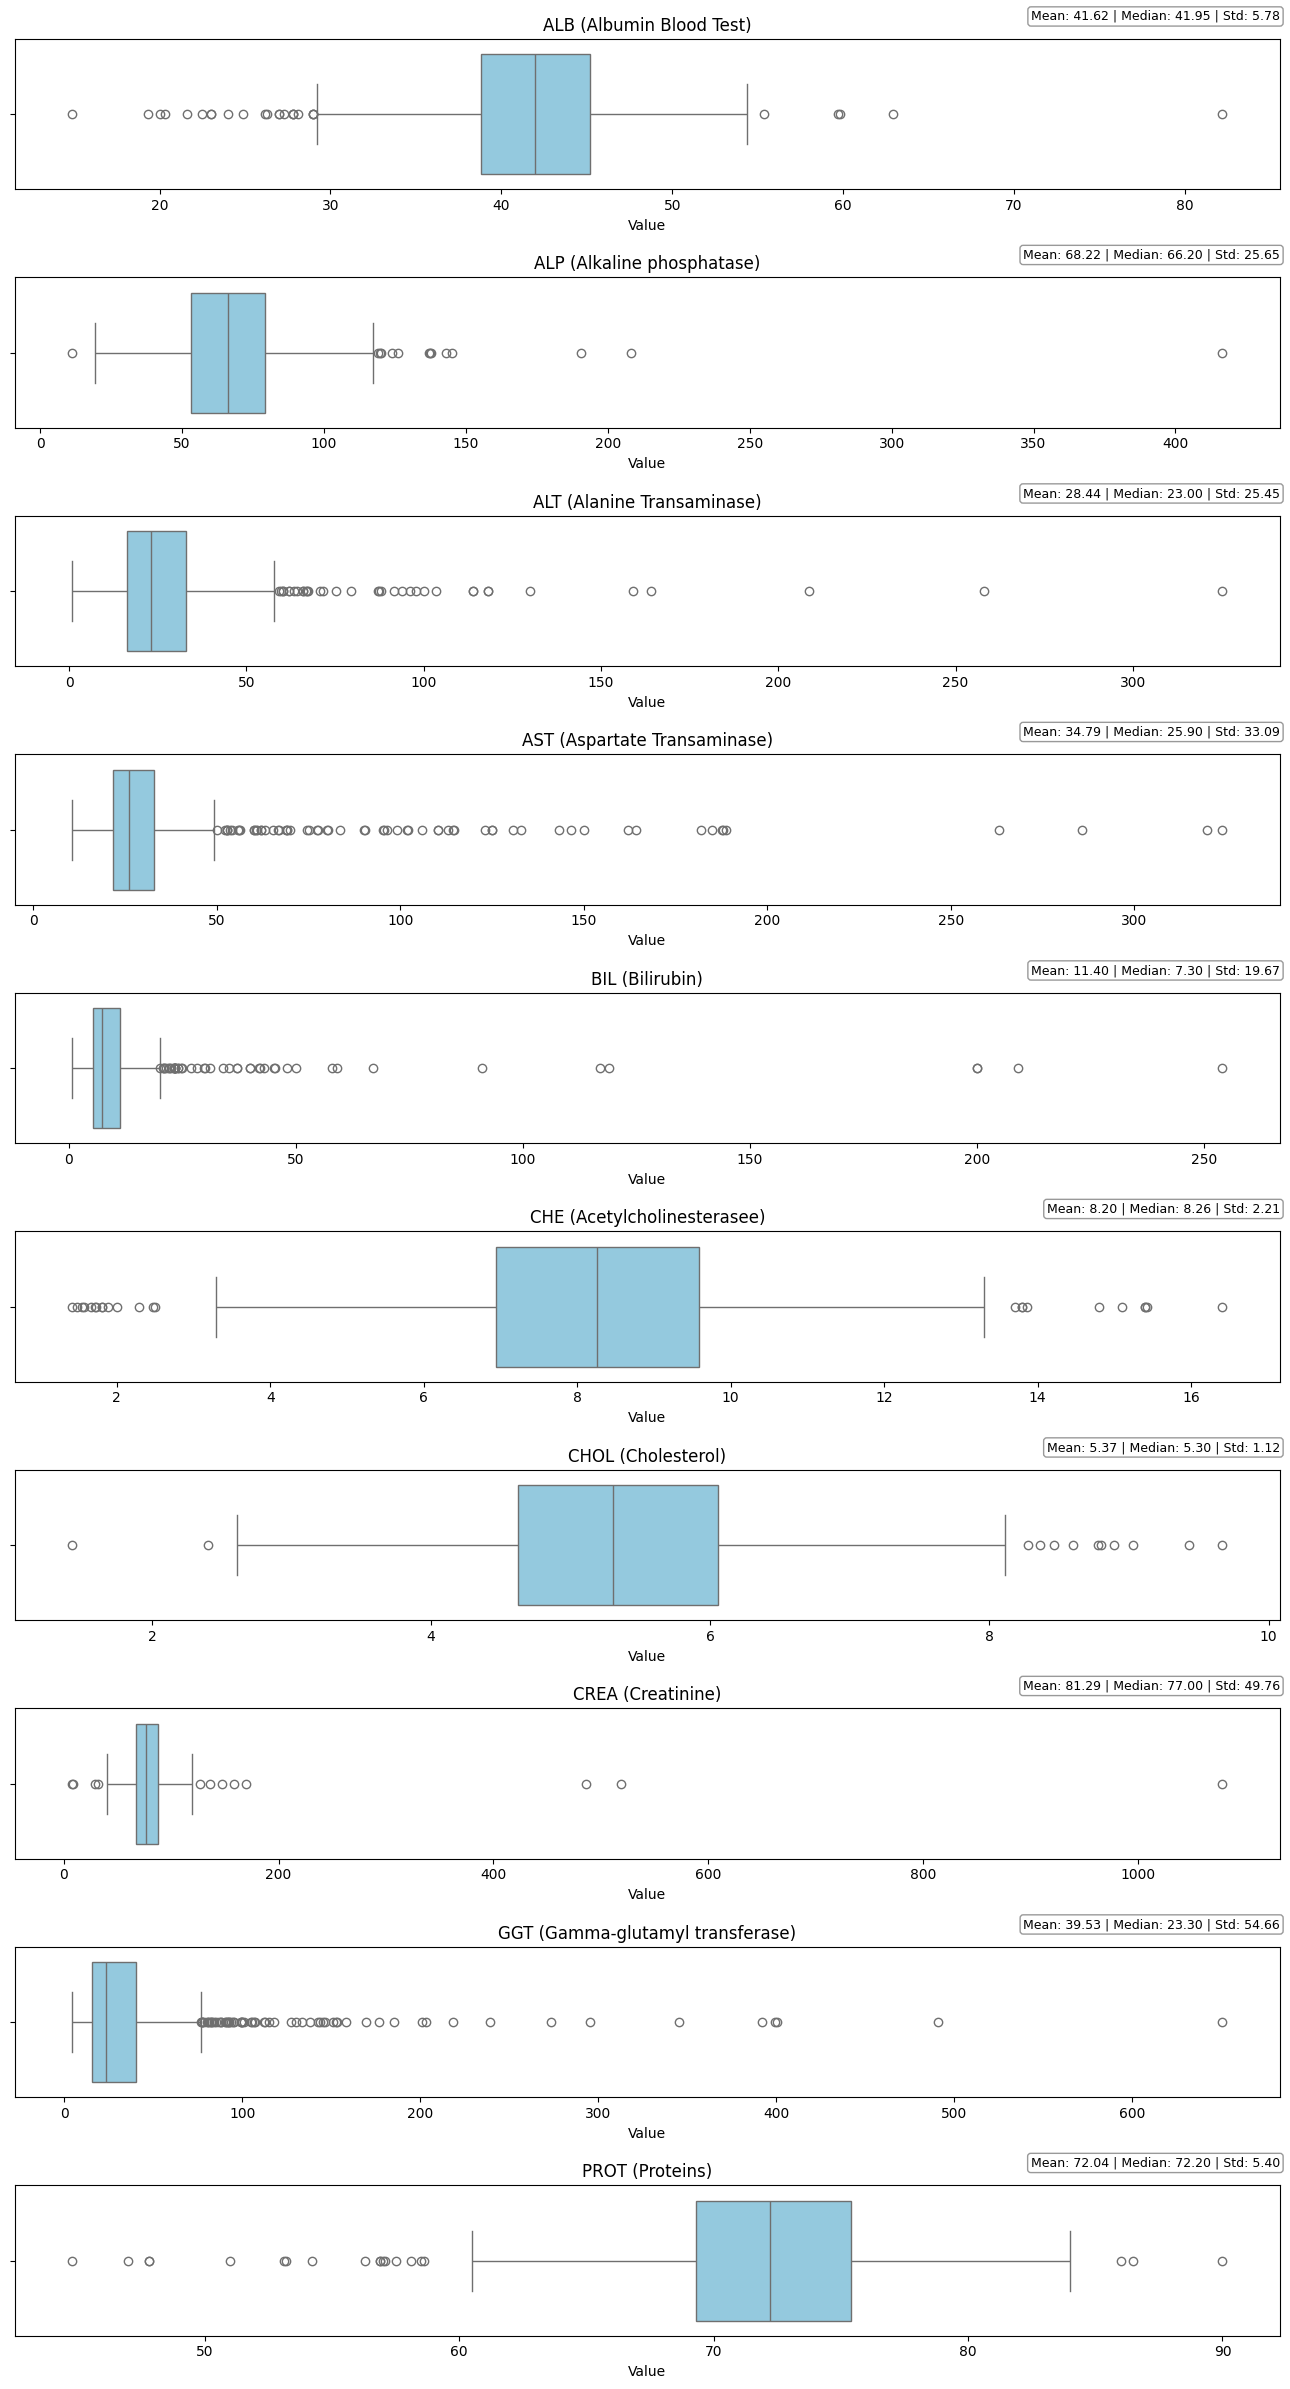

In [17]:
# Now, we can do the same for all of the laboratory attributes (box and whisker plots)
lab_features = ["ALB", "ALP", "ALT", "AST", "BIL", "CHE", "CHOL", "CREA", "GGT", "PROT"]
lab_details = [
    "Albumin Blood Test",
    "Alkaline phosphatase", 
    "Alanine Transaminase", 
    "Aspartate Transaminase", 
    "Bilirubin", 
    "Acetylcholinesterasee", 
    "Cholesterol", 
    "Creatinine", 
    "Gamma-glutamyl transferase", 
    "Proteins"]

fig, axes = plt.subplots(len(lab_features), 1, figsize=(13, 2.4 * len(lab_features)))

for i, (col, detail) in enumerate(zip(lab_features, lab_details)):
    series = df[col].dropna()
    mean = series.mean()
    median = series.median()
    std = series.std()
    summary = f"Mean: {mean:.2f} | Median: {median:.2f} | Std: {std:.2f}"

    sns.boxplot(x=series, ax=axes[i], color="skyblue")
    axes[i].set_title(f"{col} ({detail})")
    axes[i].set_xlabel("Value")
    axes[i].text(1, 1.15, summary, transform=axes[i].transAxes, ha="right", va="center", fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="gray"))

plt.tight_layout()
plt.show()


{'ALB': 31, 'ALP': 13, 'ALT': 20, 'AST': 27, 'BIL': 10, 'CHE': 34, 'CHOL': 28, 'CREA': 3, 'GGT': 19, 'PROT': 25}


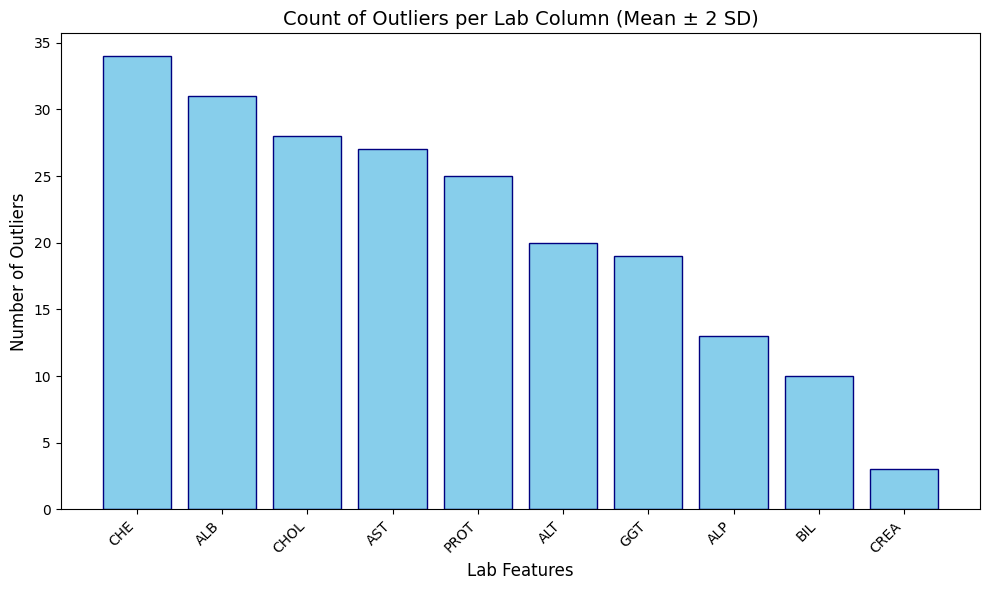

In [29]:
# Next, let's look at the count of outliers per lab column (mean +/- 2 standard deviations)
outliers_by_lab_col = {}

for col in lab_features:
    mean = df[col].mean()
    std = df[col].std()
    lower = mean - 2 * std
    upper = mean + 2 * std
    outliers_by_lab_col[col] = df[(df[col] < lower) | (df[col] > upper)].shape[0]

print(outliers_by_lab_col)

# plotting the outliers

outliers_df = pd.DataFrame(list(outliers_by_lab_col.items()), columns=['Lab Feature', 'Outlier Count'])

outliers_df = outliers_df.sort_values(by='Outlier Count', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(outliers_df['Lab Feature'], outliers_df['Outlier Count'], color='skyblue', edgecolor='navy')

plt.xlabel('Lab Features', fontsize=12)
plt.ylabel('Number of Outliers', fontsize=12)
plt.title('Count of Outliers per Lab Column (Mean ± 2 SD)', fontsize=14)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

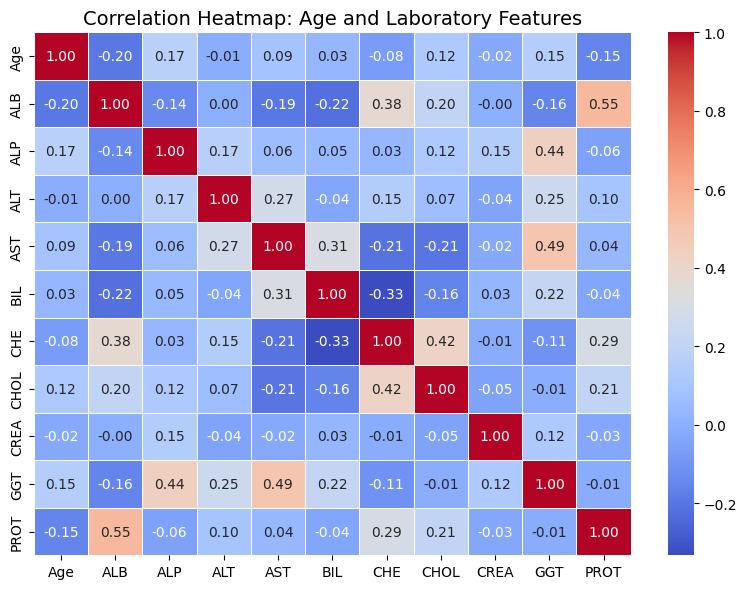

In [34]:
# Correlation matrix for laboratory fields only
cols = ["Age"] + lab_features
corr_matrix = df[cols].corr()

# making a heatmap for the correlation matrix

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: Age and Laboratory Features', fontsize=14)
plt.tight_layout()

plt.show()

In [20]:
# Next, we will set up hypothesis testing for a series of tests to come
from itertools import combinations
from scipy.stats import chi2_contingency, f_oneway, kruskal, mannwhitneyu, binomtest

category_labels = {0: "Blood Donor", 1: "Hepatitis", 2: "Fibrosis", 3: "Cirrhosis"}
sex_labels = {0: "Female", 1: "Male"}

df_test = df.copy()
df_test["CategoryName"] = df_test["Category"].map(category_labels)
df_test["SexName"] = df_test["Sex"].map(sex_labels)

lab_cols = ["ALB", "ALP", "ALT", "AST", "BIL", "CHE", "CHOL", "CREA", "GGT", "PROT"]
feature_cols = ["Age"] + lab_cols
categories = sorted(df_test["Category"].dropna().unique())


In [21]:
# First, let's look at Sex vs Category association using a Chi-square test
sex_cat_ct = pd.crosstab(df_test["SexName"], df_test["CategoryName"])
chi2, p_chi2, dof, expected = chi2_contingency(sex_cat_ct)

print(sex_cat_ct)
print(f"Chi2={chi2:.4f}, p={p_chi2:.4g}, dof={dof}")


CategoryName  Blood Donor  Cirrhosis  Fibrosis  Hepatitis
SexName                                                  
Female                216         10         8          4
Male                  324         20        13         20
Chi2=5.6635, p=0.1292, dof=3


We did not find a statistically significant association between sex and category in our dataset, as p=0.129

In [22]:
# Now, we will use a binomial test, which will tell us, for each category, whether the male proportion
# in this category is significantly different from the overall proportion in the whole dataset.
# Note that category in our dataset refers to Blood Donor, Hepatitis, Fibrosis, and Cirrhosis/

overall_male_rate = (df_test["Sex"] == 1).mean()
test_results = []
for cat in categories:
    sub = df_test[df_test["Category"] == cat]
    n_cat = len(sub)
    male_count = int((sub["Sex"] == 1).sum())
    female_count = int((sub["Sex"] == 0).sum())
    p_binom = binomtest(male_count, n_cat, p=overall_male_rate, alternative="two-sided").pvalue
    test_results.append({
        "Category": category_labels[cat],
        "N": n_cat,
        "Male": male_count,
        "Female": female_count,
        "Male_rate": male_count / n_cat if n_cat > 0 else np.nan,
        "Overall_male_rate": overall_male_rate,
        "p_binom": p_binom
    })
test_results_df = pd.DataFrame(test_results)
display(test_results_df)


,Category,N,Male,Female,Male_rate,Overall_male_rate,p_binom
0,Blood Donor,540,324,216,0.600000,0.613008,0.536517
1,Hepatitis,24,20,4,0.833333,0.613008,0.034018
2,Fibrosis,21,13,8,0.619048,0.613008,1.000000
3,Cirrhosis,30,20,10,0.666667,0.613008,0.580853


Interpreting this test tells us that Hepatitis is the only category that came out significant at the 0.05 level, suggesting that this group has a higher male proportion than expected based on the overall male rate of our dataset.

In [23]:
# Now, let's at whether each numeric feature differs across the 4 categories overall.
result_rows = []
for feat in feature_cols:
    groups = [df_test.loc[df_test["Category"] == cat, feat].dropna().values for cat in categories]
    if all(len(g) > 1 for g in groups):
        f_stat, p_anova = f_oneway(*groups)
        h_stat, p_kruskal = kruskal(*groups)

        result_rows.append({
            "Feature": feat,
            "ANOVA_F": f_stat,
            "ANOVA_p": p_anova,
            "Kruskal_H": h_stat,
            "Kruskal_p": p_kruskal
        })
result_df = pd.DataFrame(result_rows)
display(result_df)


,Feature,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p
0,Age,11.940157,1.318064e-07,29.098353,2.135352e-06
1,ALB,28.745777,2.134976e-17,55.998433,4.204172e-12
2,ALP,17.244577,9.254460e-11,46.196793,5.150542e-10
3,ALT,11.771256,1.663988e-07,22.066434,6.318748e-05
4,AST,141.436468,1.362926e-69,155.103774,2.087700e-33
5,BIL,91.165092,9.168611e-49,94.561523,2.293746e-20
6,CHE,53.699560,8.117300e-31,66.587764,2.294400e-14
7,CHOL,19.717587,3.273604e-12,51.589324,3.663758e-11
8,CREA,14.847303,2.427382e-09,9.487463,2.346511e-02
9,GGT,54.365113,3.705367e-31,103.102781,3.343824e-22


Global ANOVA and Kruskal-Wallis tests showed significant differences across categories for all examined features, indicating that at least one disease group differs from the others for each variable. This is an intuitive result.

In [24]:
# Since we just ran ANOVA tests, we can perform post hoc tests per feature: Tukey HSD (SciPy)
from scipy.stats import tukey_hsd

posthoc_rows = []
for feat in feature_cols:
    groups = []
    names = []
    for cat in categories:
        vals = df_test.loc[df_test["Category"] == cat, feat].dropna().values
        if len(vals) >= 2:
            groups.append(vals)
            names.append(category_labels[cat])

    if len(groups) >= 2:
        res = tukey_hsd(*groups)
        for i in range(len(names)):
            for j in range(i + 1, len(names)):
                posthoc_rows.append({
                    "Feature": feat,
                    "Group1": names[i],
                    "Group2": names[j],
                    "Mean_diff": float(res.statistic[i, j]),
                    "p_tukey": float(res.pvalue[i, j])
                })

posthoc_df = pd.DataFrame(posthoc_rows)
display(posthoc_df.sort_values(["Feature", "p_tukey"]))

print("Significant post hoc differences (Tukey p < 0.05):")
display(posthoc_df[posthoc_df["p_tukey"] < 0.05].sort_values(["Feature", "p_tukey"]))


,Feature,Group1,Group2,Mean_diff,p_tukey
8,ALB,Blood Donor,Cirrhosis,9.208704,1.765255e-14
10,ALB,Hepatitis,Cirrhosis,11.035000,2.162270e-12
11,ALB,Fibrosis,Cirrhosis,8.963571,5.946114e-08
6,ALB,Blood Donor,Hepatitis,-1.826296,3.707664e-01
9,ALB,Hepatitis,Fibrosis,2.071429,5.766959e-01
...,...,...,...,...,...
61,PROT,Blood Donor,Fibrosis,-4.224630,2.138737e-03
64,PROT,Hepatitis,Cirrhosis,4.576667,9.410397e-03
60,PROT,Blood Donor,Hepatitis,-2.824630,5.379246e-02
62,PROT,Blood Donor,Cirrhosis,1.752037,2.949026e-01


Significant post hoc differences (Tukey p < 0.05):


,Feature,Group1,Group2,Mean_diff,p_tukey
8,ALB,Blood Donor,Cirrhosis,9.208704,1.765255e-14
10,ALB,Hepatitis,Cirrhosis,11.035000,2.162270e-12
11,ALB,Fibrosis,Cirrhosis,8.963571,5.946114e-08
16,ALP,Hepatitis,Cirrhosis,-42.691667,3.118896e-09
17,ALP,Fibrosis,Cirrhosis,-37.821429,6.186401e-07
12,ALP,Blood Donor,Hepatitis,23.744815,2.891485e-05
14,ALP,Blood Donor,Cirrhosis,-18.946852,2.828571e-04
13,ALP,Blood Donor,Fibrosis,18.874577,3.498362e-03
19,ALT,Blood Donor,Fibrosis,-31.990000,6.441535e-08
23,ALT,Fibrosis,Cirrhosis,36.630000,1.710273e-06


Significant comparisons to plot: 40


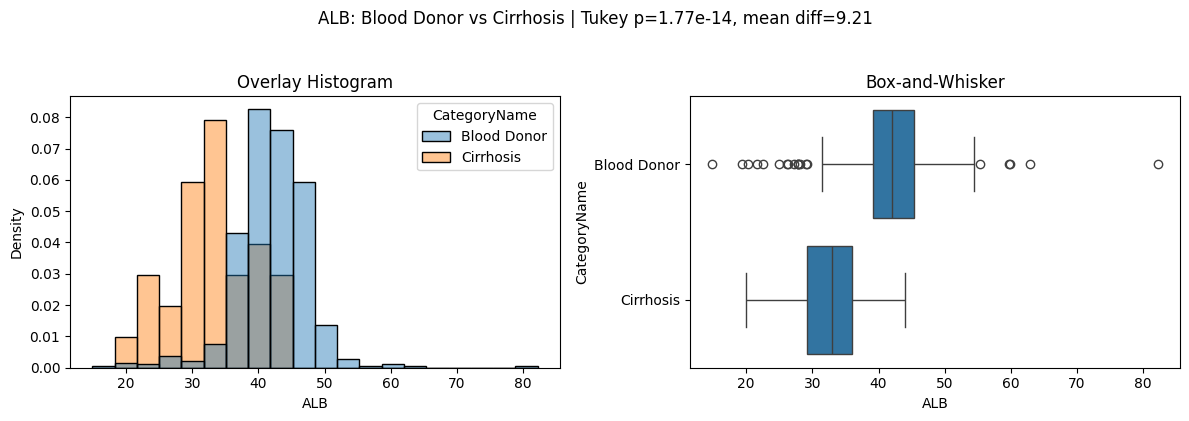

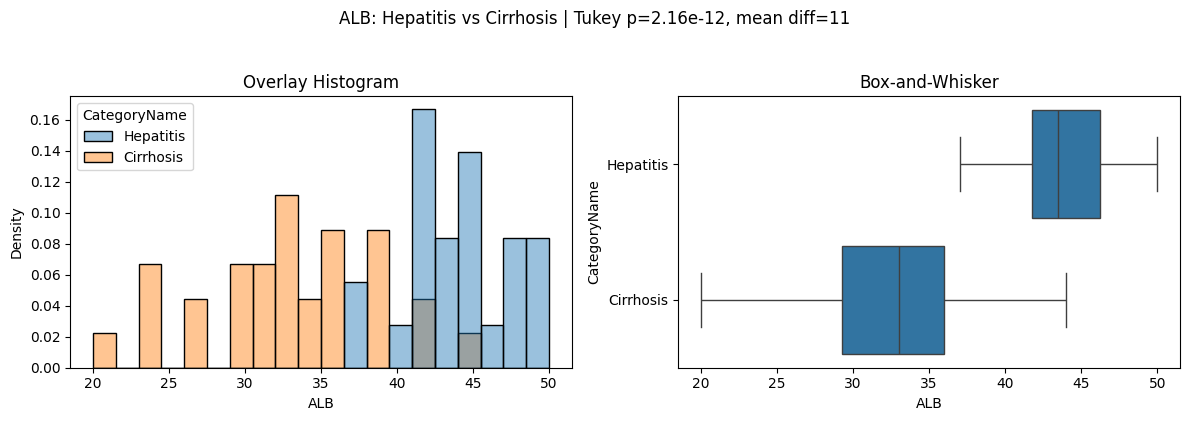

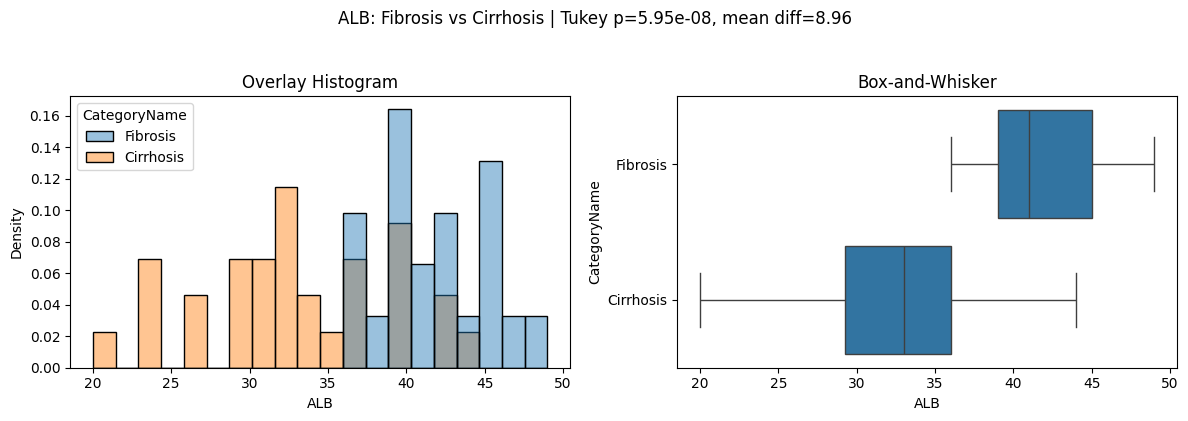

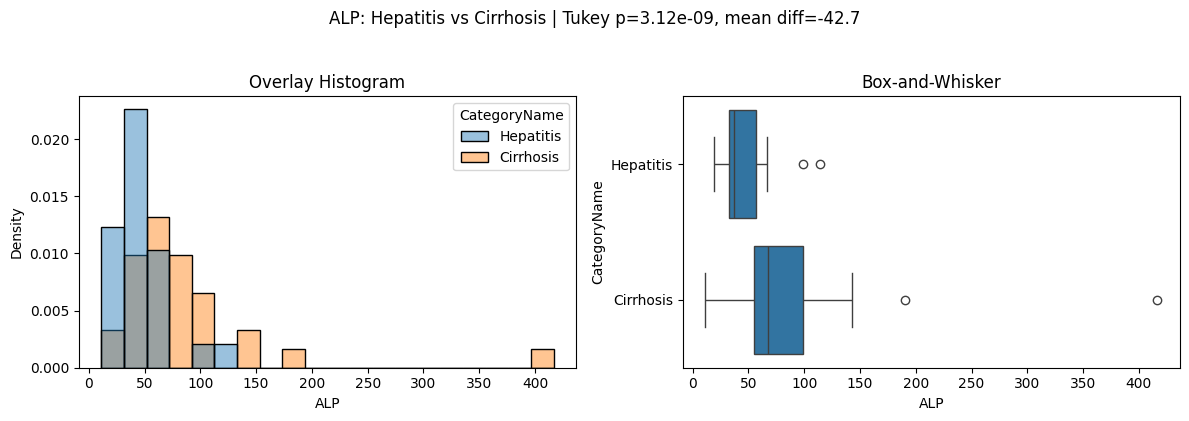

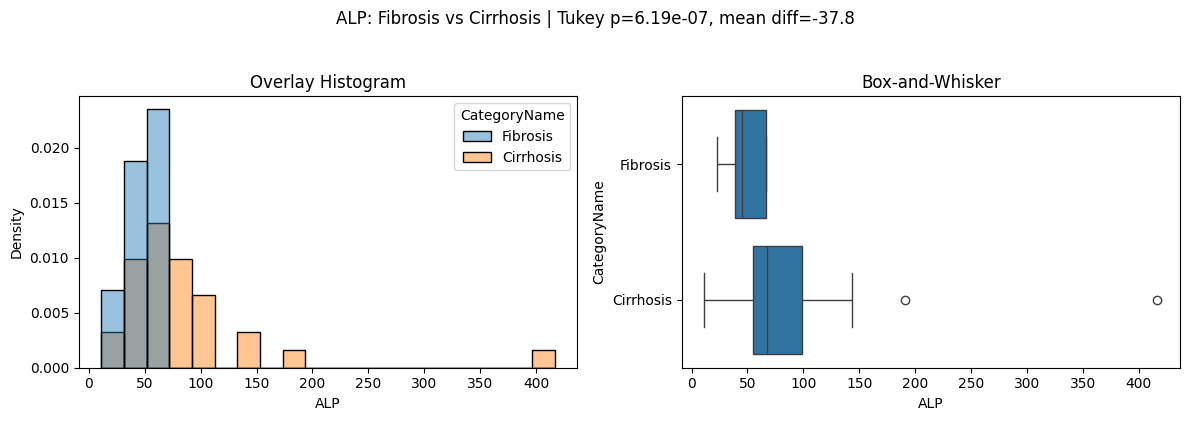

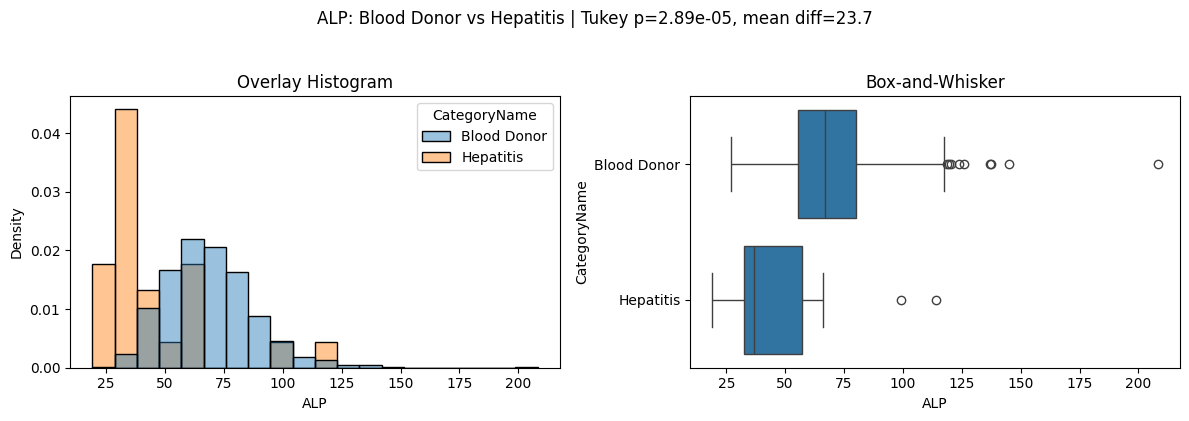

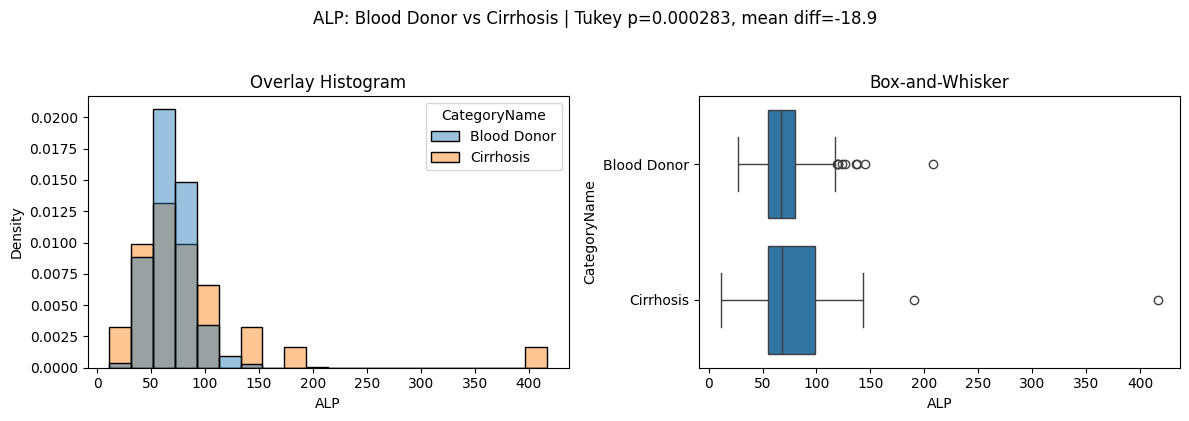

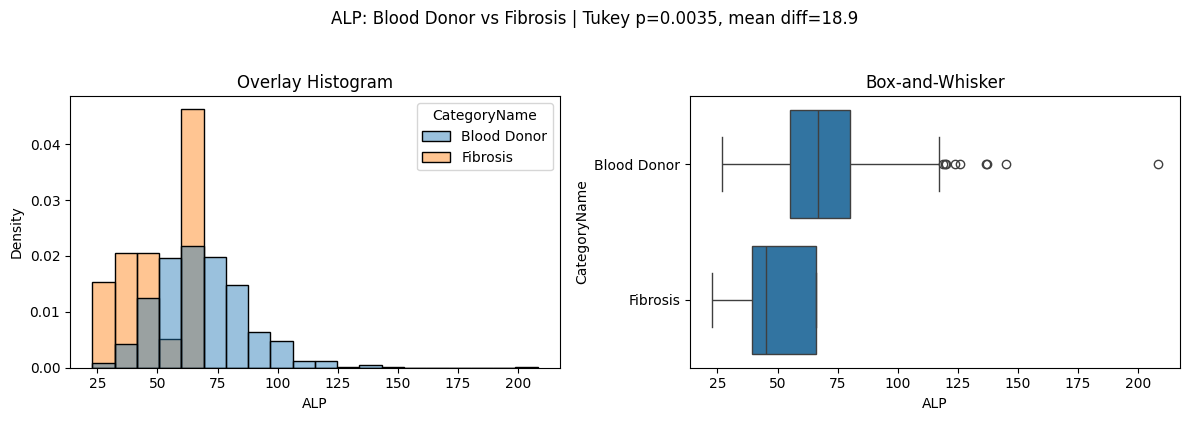

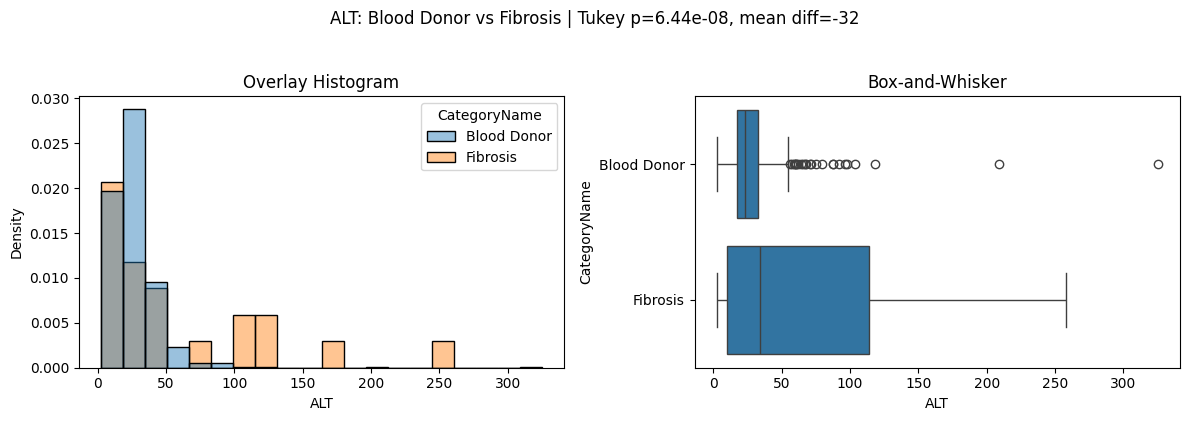

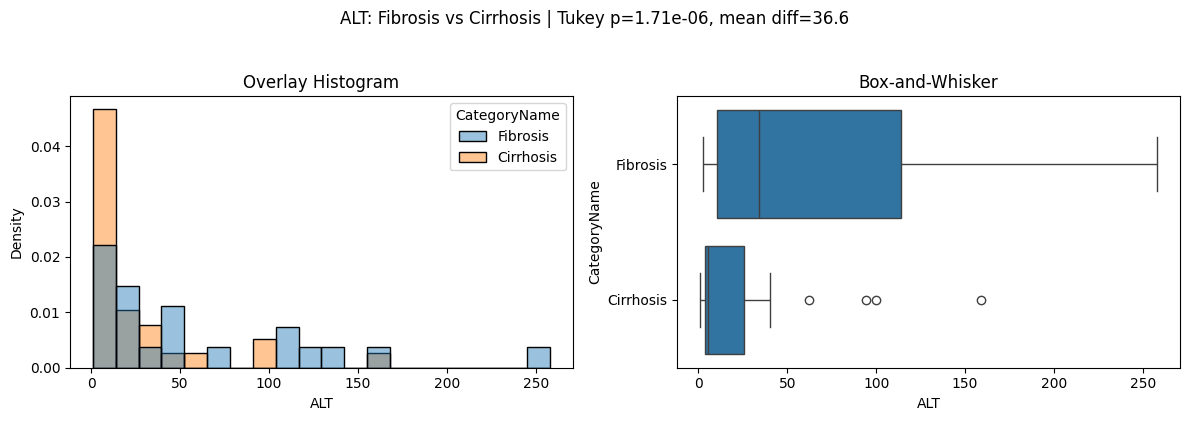

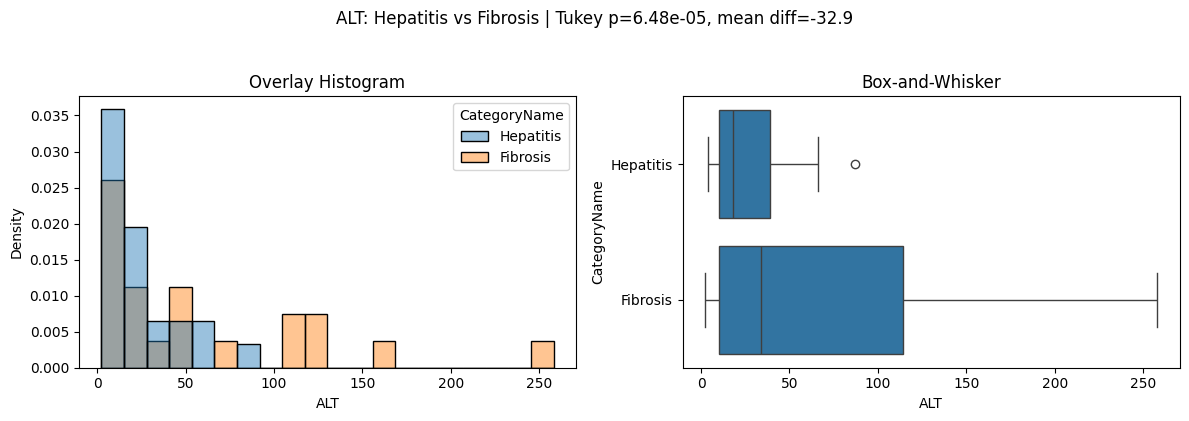

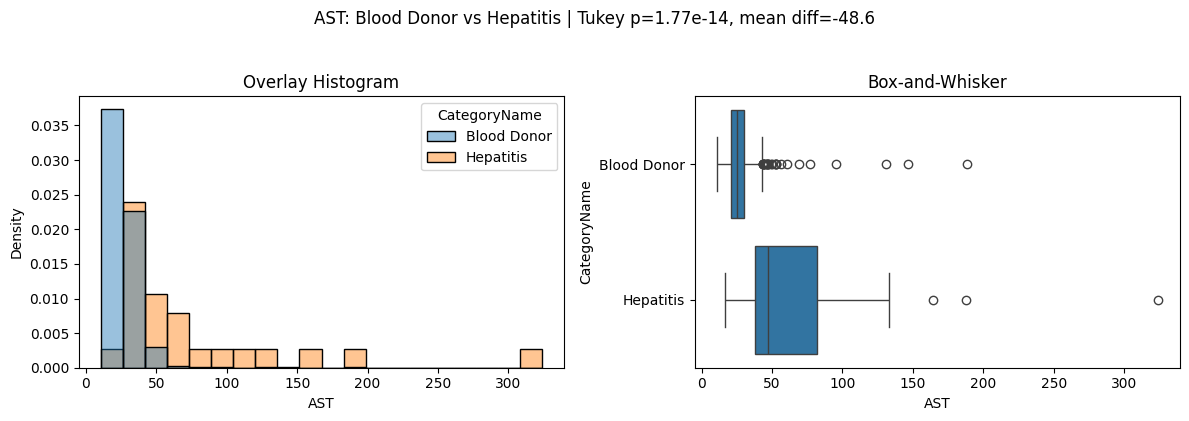

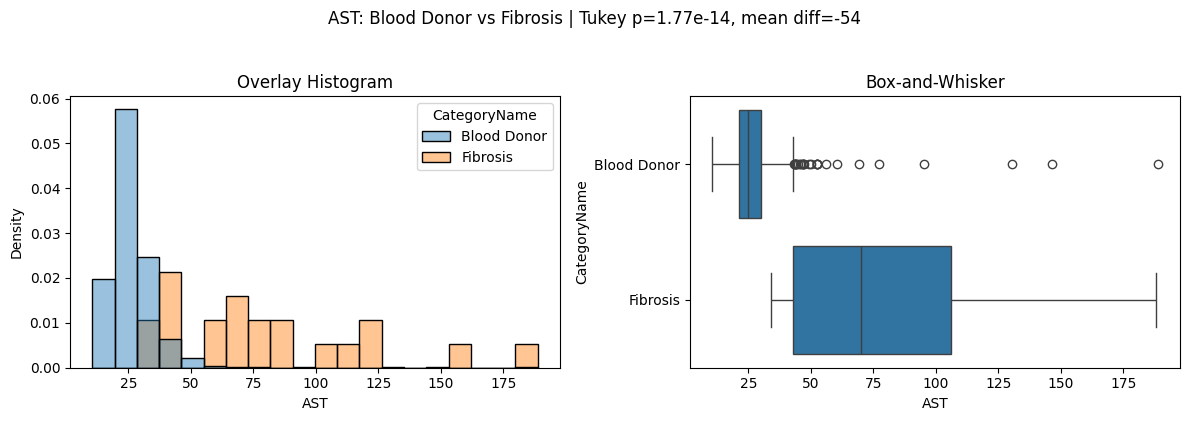

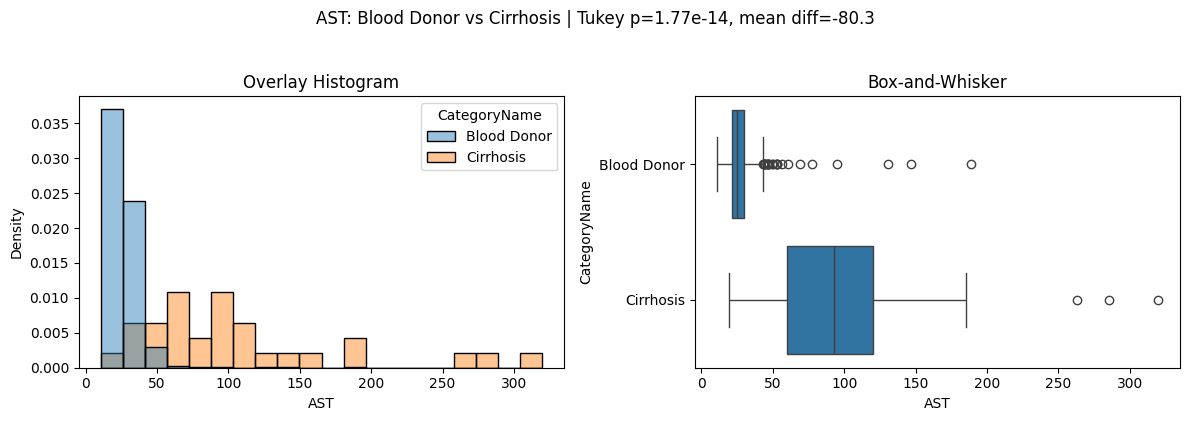

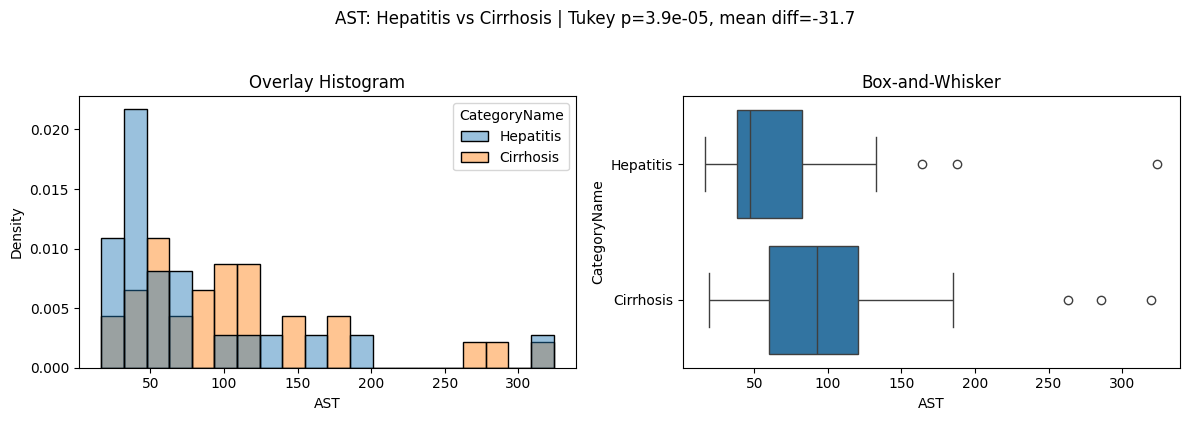

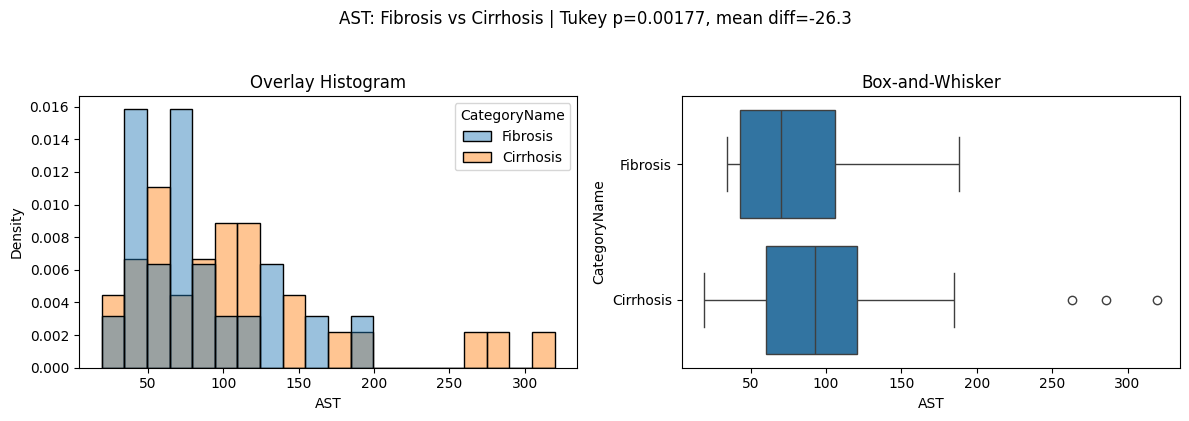

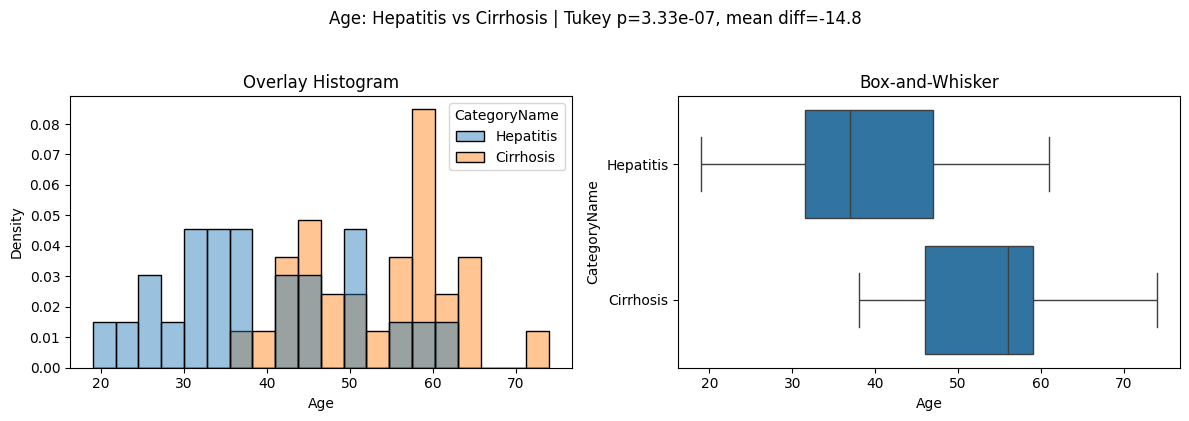

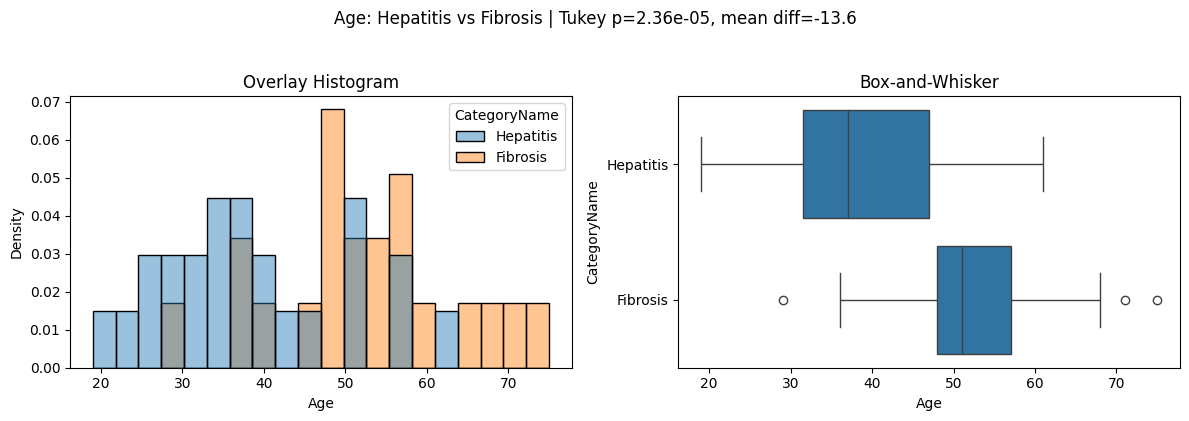

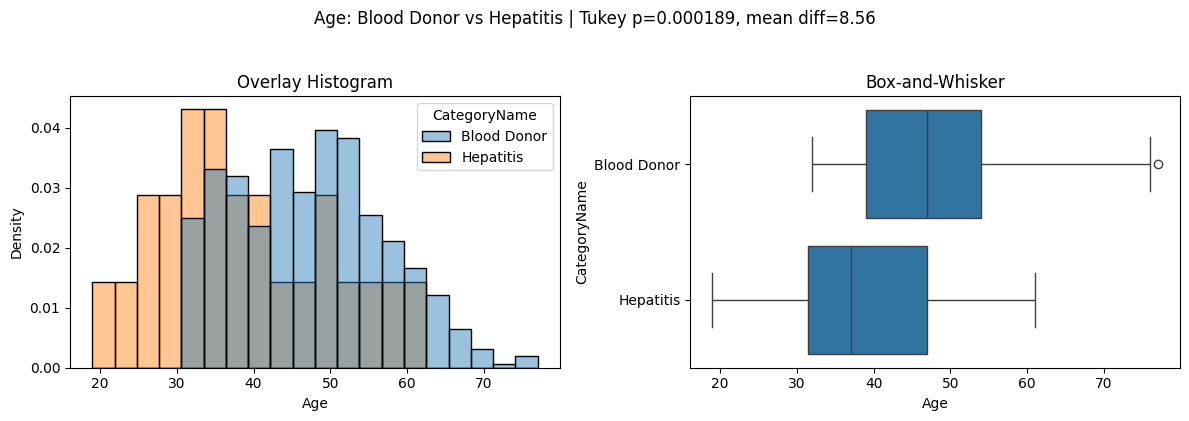

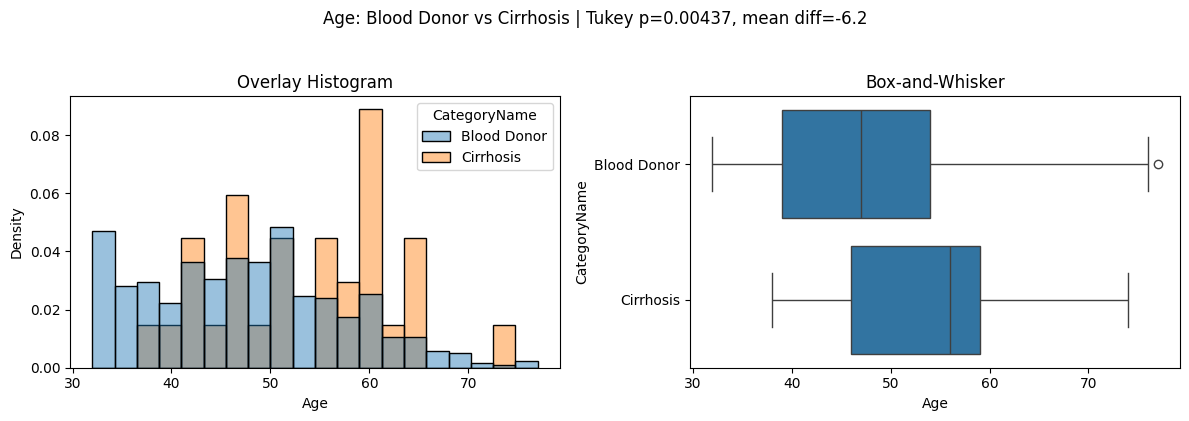

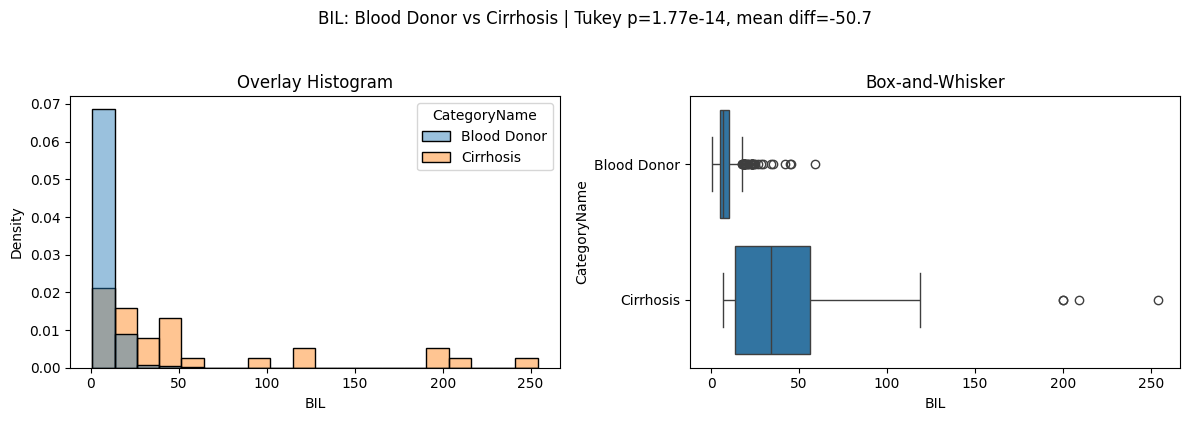

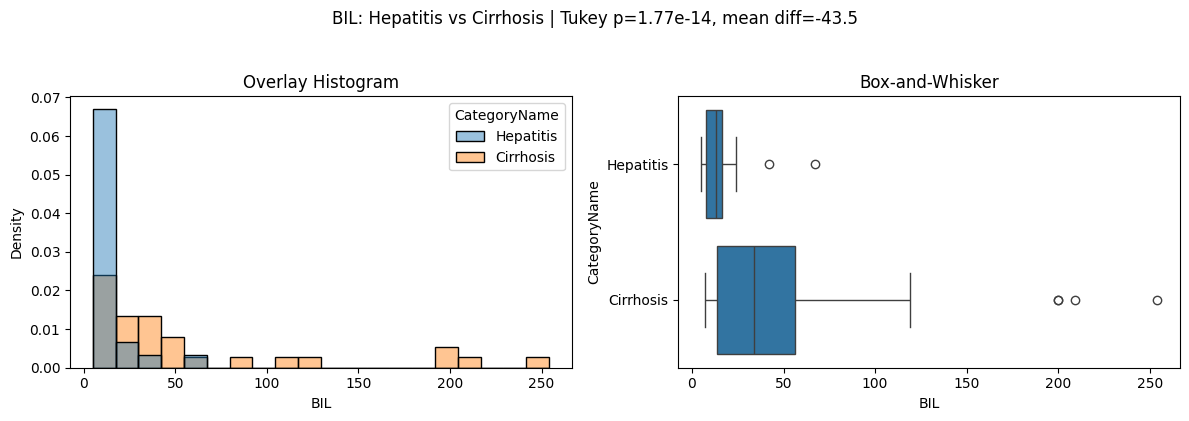

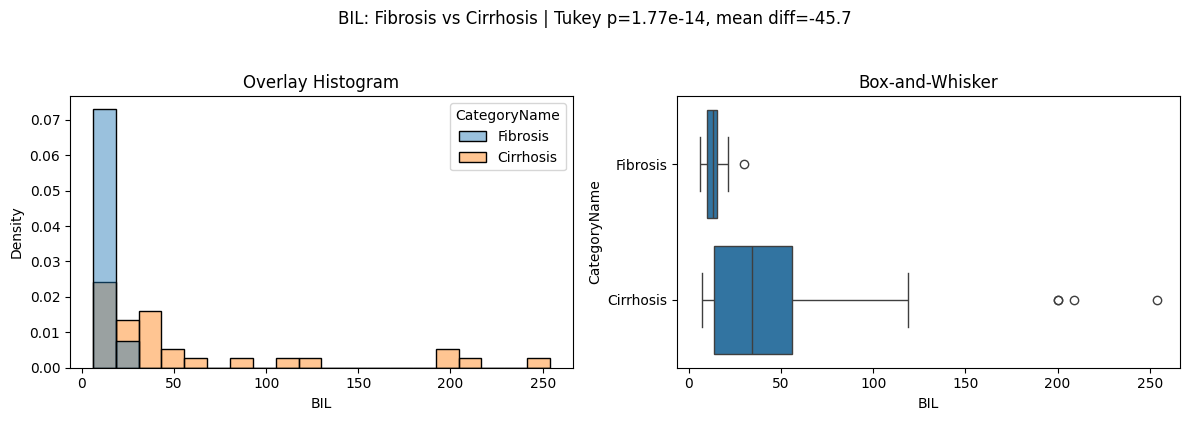

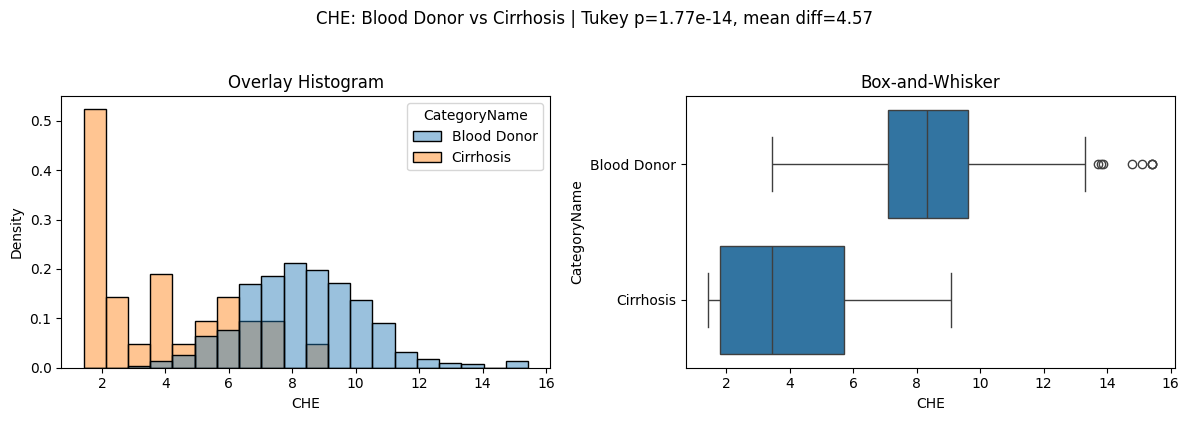

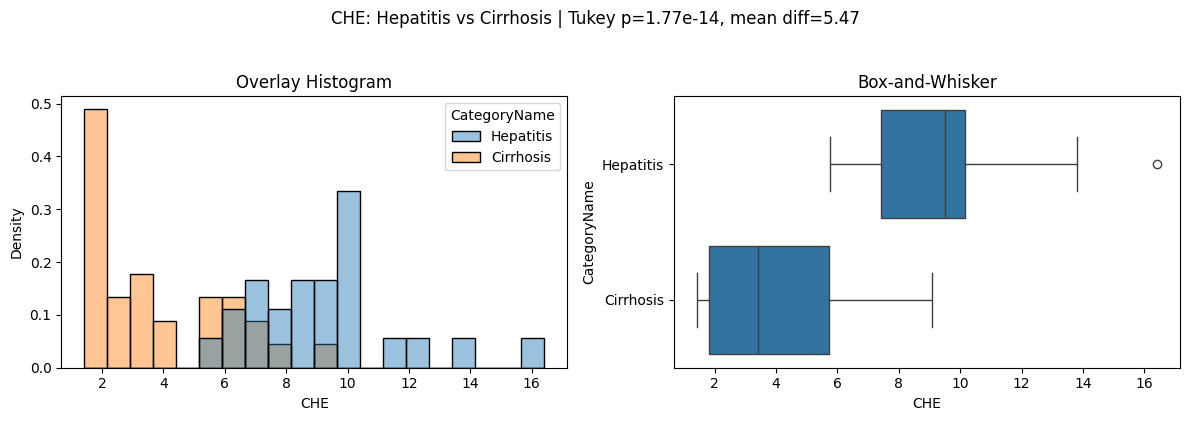

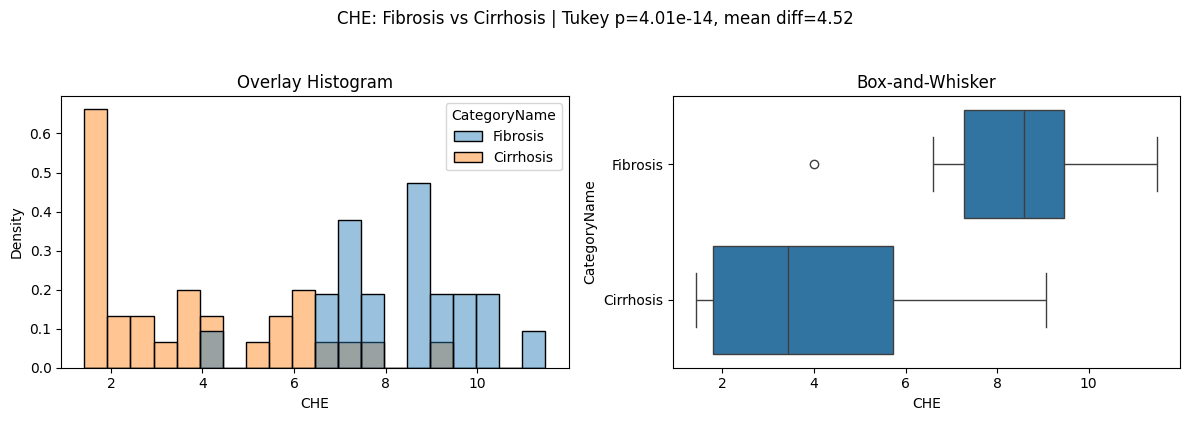

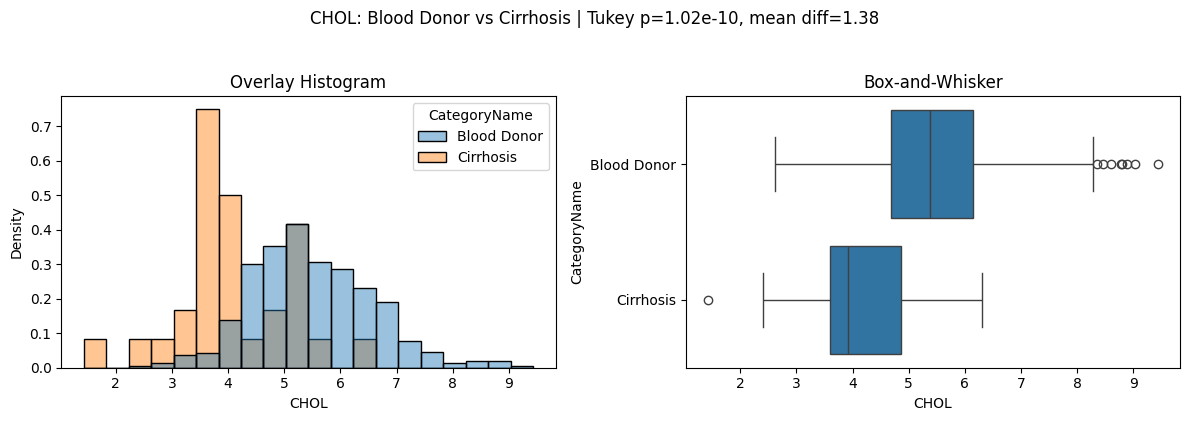

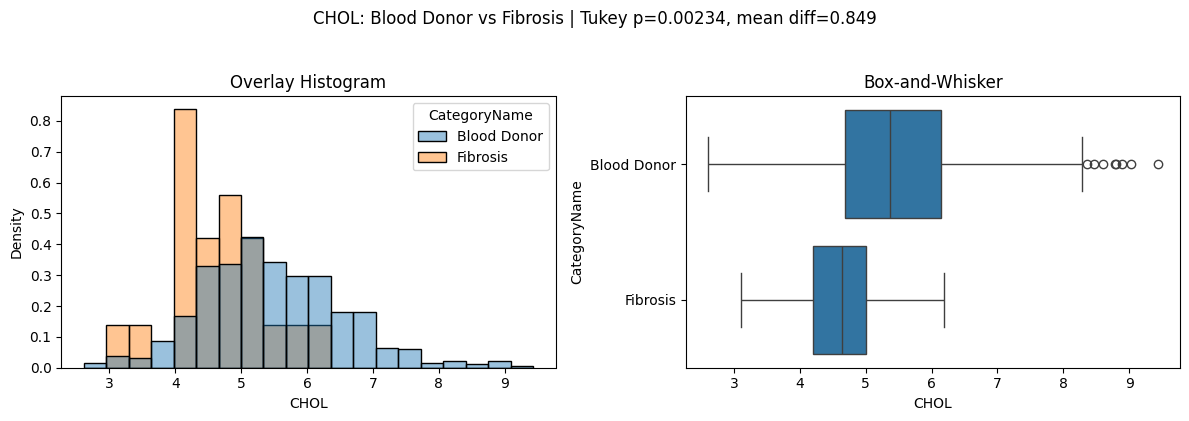

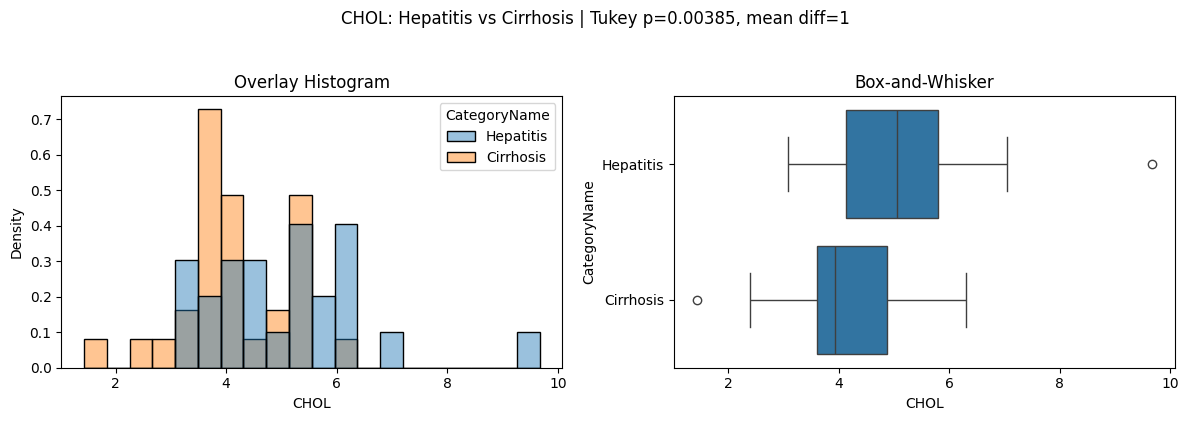

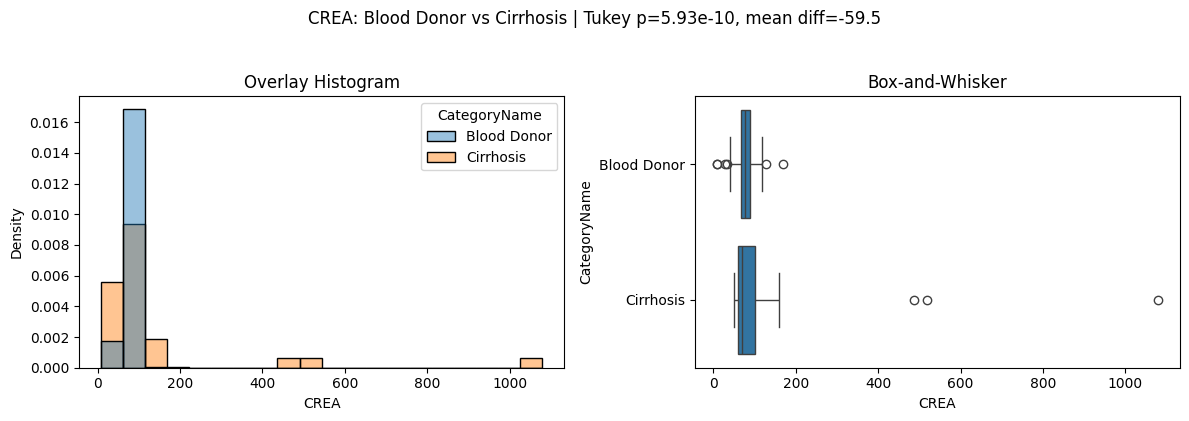

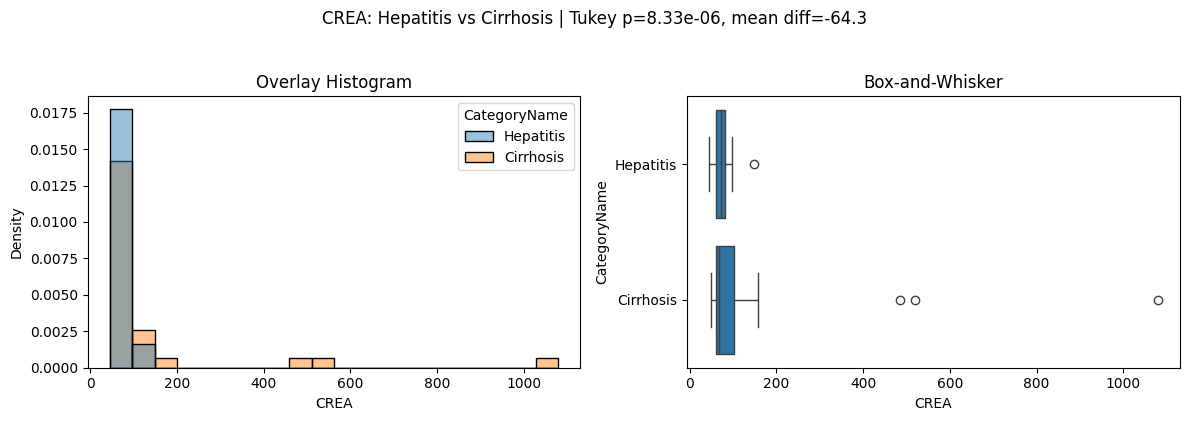

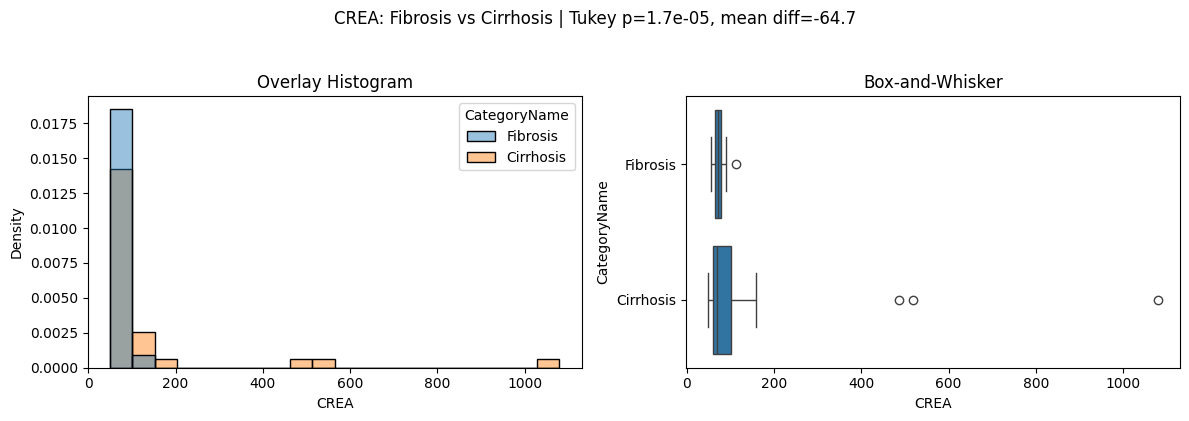

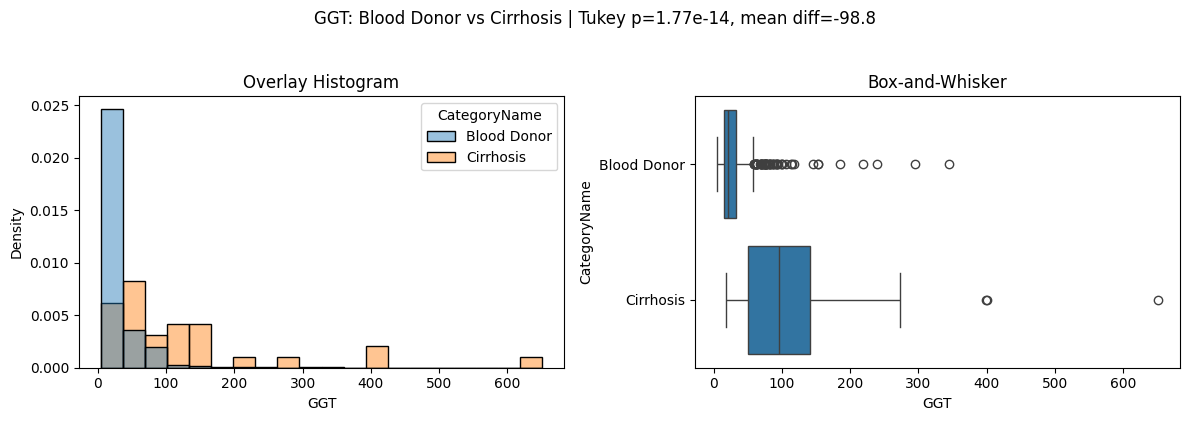

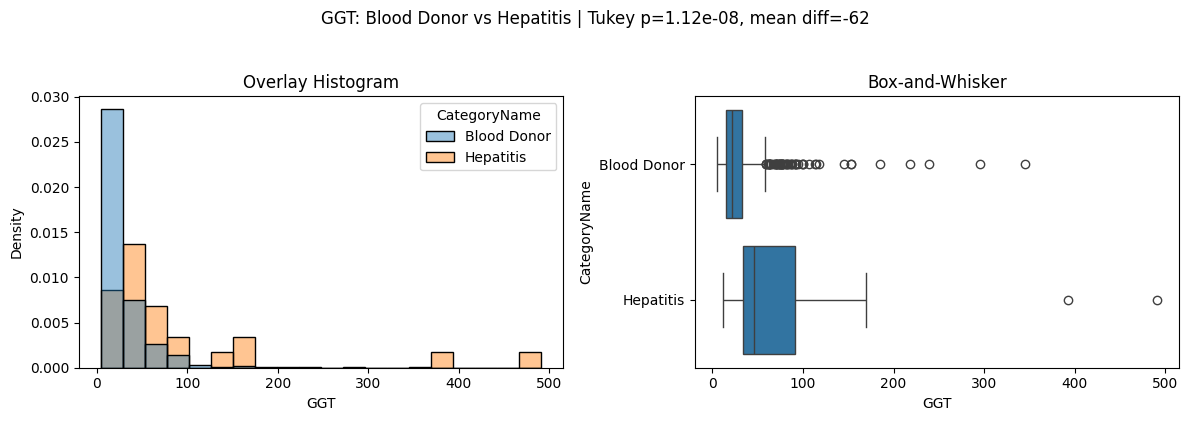

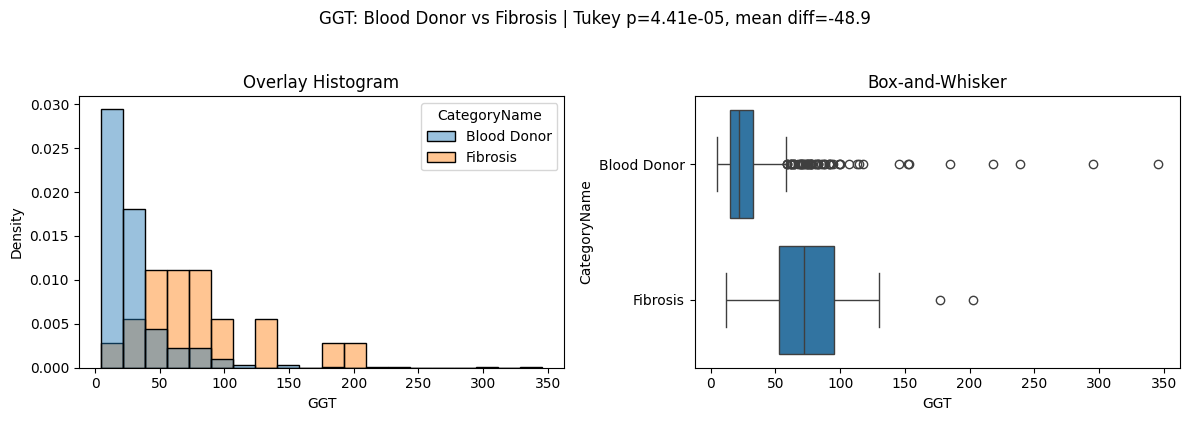

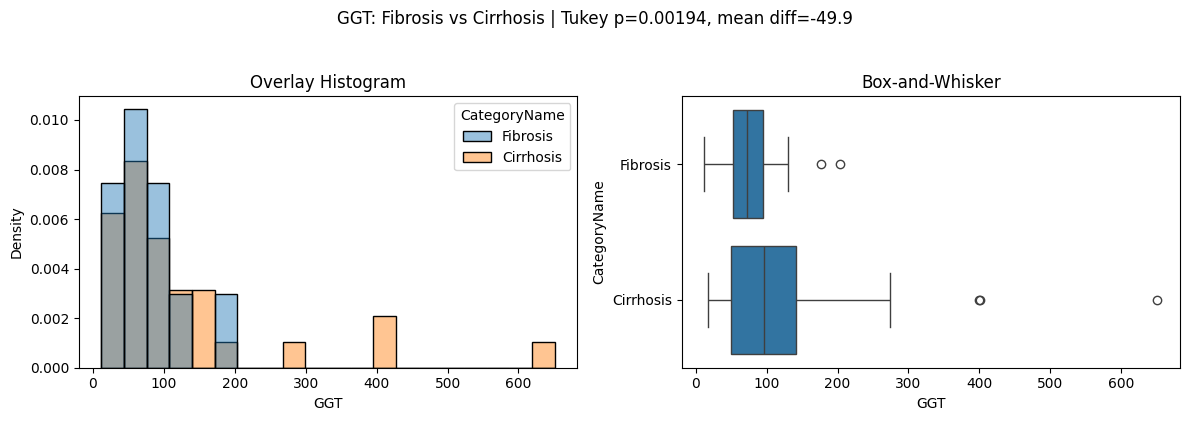

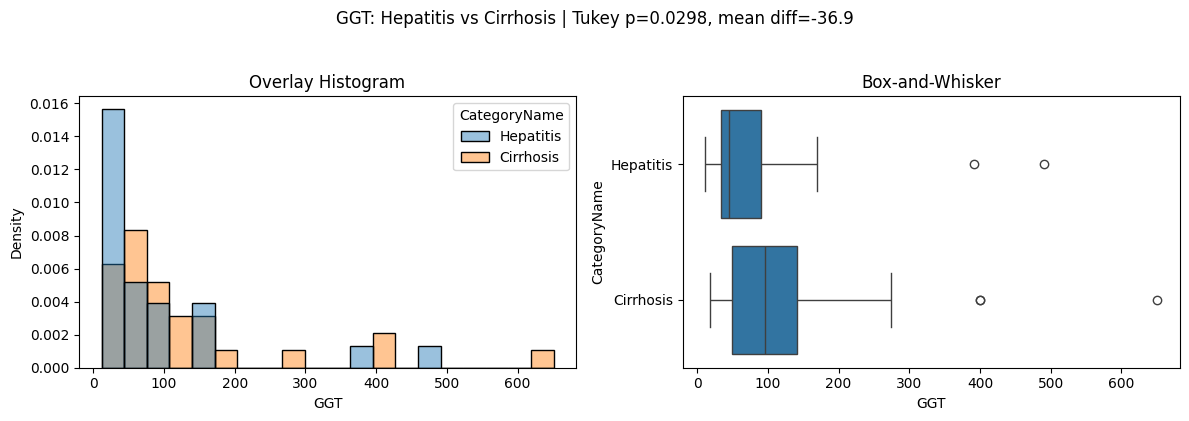

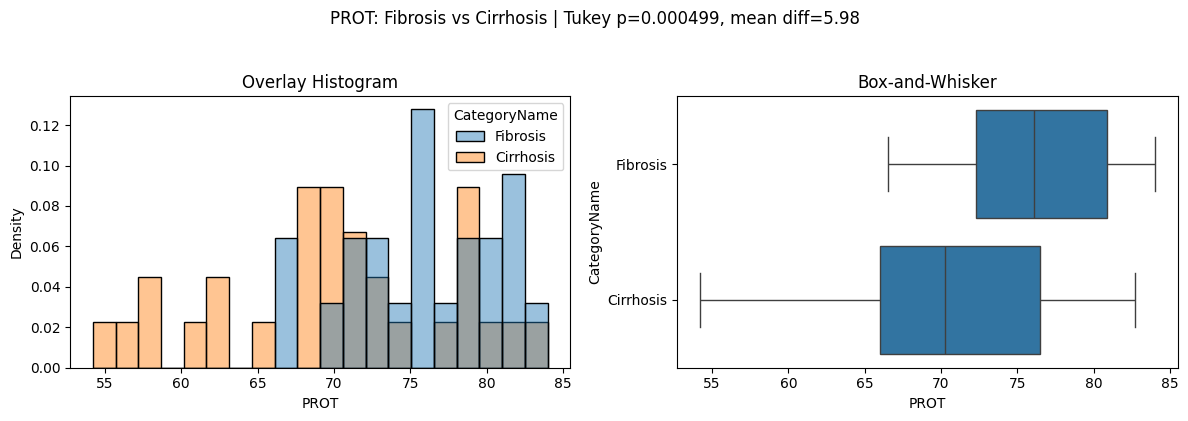

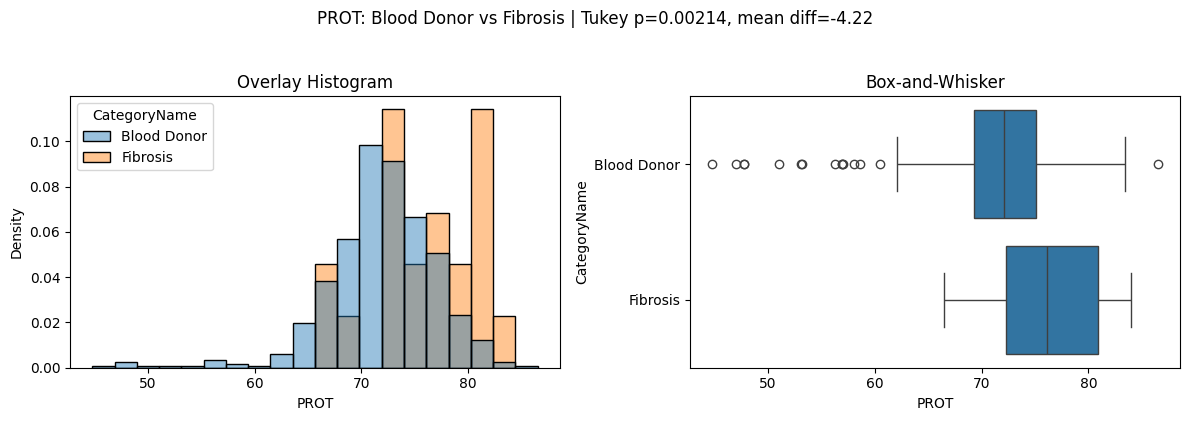

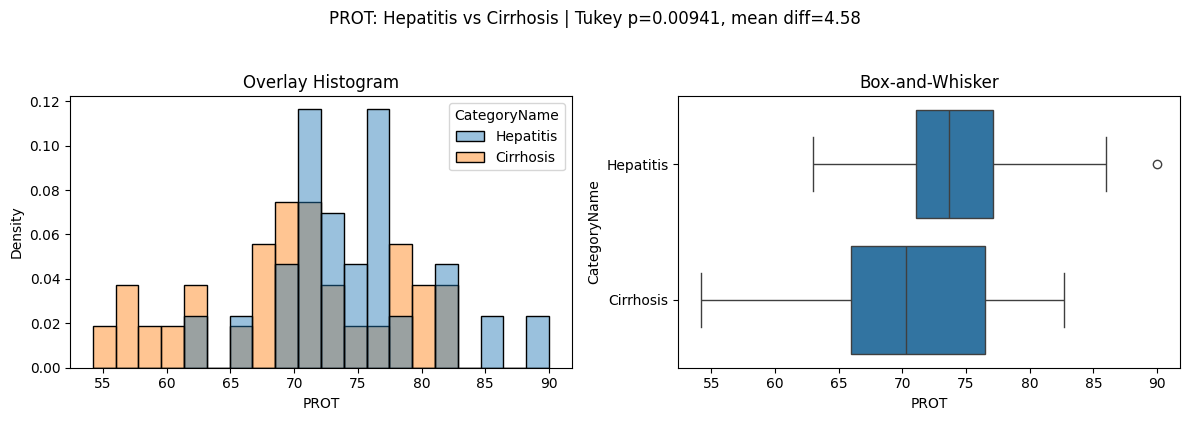

In [25]:
# Now we create plots for all (40) significant Tukey post hoc comparisons
sig_posthoc = posthoc_df[posthoc_df["p_tukey"] < 0.05].copy()
sig_posthoc = sig_posthoc.sort_values(["Feature", "p_tukey"])

print(f"Significant comparisons to plot: {len(sig_posthoc)}")

for _, row in sig_posthoc.iterrows():
    feat = row["Feature"]
    g1 = row["Group1"]
    g2 = row["Group2"]
    pval = row["p_tukey"]
    mdiff = row["Mean_diff"]

    sub = df_test[df_test["CategoryName"].isin([g1, g2])][["CategoryName", feat]].dropna().copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{feat}: {g1} vs {g2} | Tukey p={pval:.3g}, mean diff={mdiff:.3g}", y=1.04)

    # Same-plot distribution overlay
    sns.histplot(data=sub, x=feat, hue="CategoryName", bins=20, stat="density", common_norm=False, alpha=0.45, ax=axes[0])
    axes[0].set_title("Overlay Histogram")

    # Same-plot box-and-whisker comparison
    sns.boxplot(data=sub, x=feat, y="CategoryName", order=[g1, g2], ax=axes[1])
    axes[1].set_title("Box-and-Whisker")

    plt.tight_layout()
    plt.show()


In [26]:
# Next, we can compare each pair of categories per feature using Mann-Whitney U tests,
# which will give us a non-parametric effect size (Cliff's delta) in addition to the p-value.
pairwise_rows = []
for feat in feature_cols:
    for c1, c2 in combinations(categories, 2):
        g1 = df_test.loc[df_test["Category"] == c1, feat].dropna().values
        g2 = df_test.loc[df_test["Category"] == c2, feat].dropna().values
        if len(g1) >= 3 and len(g2) >= 3:
            u_stat, p_u = mannwhitneyu(g1, g2, alternative="two-sided")
            cliff_delta = (2 * u_stat / (len(g1) * len(g2))) - 1
            pairwise_rows.append({
                "Feature": feat,
                "Group1": category_labels[c1],
                "Group2": category_labels[c2],
                "n1": len(g1),
                "n2": len(g2),
                "U": u_stat,
                "p": p_u,
                "Cliffs_delta": cliff_delta
            })
pairwise_df = pd.DataFrame(pairwise_rows)
display(pairwise_df.sort_values("p").head(40))


,Feature,Group1,Group2,n1,n2,U,p,Cliffs_delta
26,AST,Blood Donor,Cirrhosis,540,30,807.5,9.934065e-17,-0.900309
38,CHE,Blood Donor,Cirrhosis,540,30,15083.5,1.812801e-15,0.862160
32,BIL,Blood Donor,Cirrhosis,540,30,1296.0,9.226962e-15,-0.840000
25,AST,Blood Donor,Fibrosis,540,21,325.0,2.236603e-13,-0.942681
56,GGT,Blood Donor,Cirrhosis,540,30,1665.0,2.321767e-13,-0.794444
8,ALB,Blood Donor,Cirrhosis,540,30,14362.0,9.890937e-13,0.773086
24,AST,Blood Donor,Hepatitis,540,24,1210.0,1.520597e-11,-0.813272
44,CHOL,Blood Donor,Cirrhosis,540,30,13450.0,1.107526e-09,0.660494
55,GGT,Blood Donor,Fibrosis,540,21,1519.5,1.236083e-08,-0.732011
10,ALB,Hepatitis,Cirrhosis,24,30,686.0,1.401940e-08,0.905556


In [27]:
# 5) Sex differences within each category for each feature
within_rows = []
for cat in categories:
    sub = df_test[df_test["Category"] == cat]
    for feat in feature_cols:
        male_vals = sub.loc[sub["Sex"] == 1, feat].dropna().values
        female_vals = sub.loc[sub["Sex"] == 0, feat].dropna().values
        if len(male_vals) >= 3 and len(female_vals) >= 3:
            u_stat, p_u = mannwhitneyu(male_vals, female_vals, alternative="two-sided")
            cliff_delta = (2 * u_stat / (len(male_vals) * len(female_vals))) - 1
            within_rows.append({
                "Category": category_labels[cat],
                "Feature": feat,
                "Male_n": len(male_vals),
                "Female_n": len(female_vals),
                "Male_median": np.median(male_vals),
                "Female_median": np.median(female_vals),
                "U": u_stat,
                "p": p_u,
                "Cliffs_delta": cliff_delta
            })
within_df = pd.DataFrame(within_rows)
display(within_df.sort_values("p"))


,Category,Feature,Male_n,Female_n,Male_median,Female_median,U,p,Cliffs_delta
8,Blood Donor,CREA,324,216,85.000,68.000,58637.0,1.897382e-40,0.675726
3,Blood Donor,ALT,324,216,27.100,18.450,50713.5,8.696171e-19,0.449288
4,Blood Donor,AST,324,216,27.050,22.100,48981.0,3.396501e-15,0.399777
9,Blood Donor,GGT,324,216,24.100,16.700,48384.5,4.717260e-14,0.382730
5,Blood Donor,BIL,324,216,7.500,5.800,45941.5,7.071764e-10,0.312914
1,Blood Donor,ALB,324,216,43.100,40.500,44350.0,1.376729e-07,0.267433
6,Blood Donor,CHE,324,216,8.695,7.795,44187.5,2.259300e-07,0.262789
10,Blood Donor,PROT,324,216,72.500,71.800,39762.0,7.247210e-03,0.136317
19,Hepatitis,CREA,20,4,77.050,59.800,69.0,2.277433e-02,0.725000
14,Hepatitis,ALT,20,4,22.200,8.600,66.0,4.536044e-02,0.650000


## Summary of Statistical Testing Completed

### 1) Data Preparation Used for All Tests
- Loaded `HepatitisCdata.csv` into a pandas DataFrame.
- Encoded `Sex` as numeric (`m -> 1`, `f -> 0`).
- Renamed `Unnamed: 0` to `id`.
- Mapped category labels into 4 analysis groups:
  - `0` = Blood Donor (including suspect donor)
  - `1` = Hepatitis
  - `2` = Fibrosis
  - `3` = Cirrhosis
- Filled missing values in selected lab features (same preprocessing used before testing).

### 2) Exploratory/Distribution Work
- Produced box-and-whisker plots for `Age` and each lab feature (`ALB, ALP, ALT, AST, BIL, CHE, CHOL, CREA, GGT, PROT`).
- Added summary memo values (mean, median, standard deviation) to plots.
- Built a correlation matrix restricted to laboratory features.

### 3) Sex vs Category Association (Categorical Test)
- Ran a **chi-square test of independence** on the contingency table of `Sex` by `Category`.
- Purpose: test whether category membership proportions differ by sex.

### 4) Category-Level Sex Enrichment
- For each category, ran a **binomial test** comparing observed male count in that category against the overall male rate in the dataset.
- Purpose: test whether a category is enriched/depleted for males relative to dataset baseline.

### 5) Global Multi-Group Feature Tests Across Categories
For each numeric feature (`Age` + all lab features), compared values across the 4 categories using:
- **One-way ANOVA** (`f_oneway`): parametric mean-difference test across groups.
- **Kruskal-Wallis** (`kruskal`): nonparametric rank-based multi-group test.
- Also computed **eta-squared** as an effect-size summary from between-group vs total variance.

Interpretation of this step:
- A significant ANOVA/Kruskal result means at least one category differs from another for that feature.
- It does **not** by itself identify which exact category pairs differ.

### 6) Pairwise Category Comparisons (Nonparametric)
- For each feature, ran pairwise **Mann-Whitney U** tests for all category pairs.
- Reported p-values and **Cliff's delta** effect size for each pair.
- Purpose: identify specific pairwise differences and their direction/magnitude.

### 7) Sex Differences Within Each Category
- Within each category, compared male vs female distributions for each feature using **Mann-Whitney U**.
- Reported p-values, medians by sex, and Cliff's delta.
- Purpose: determine whether sex-related feature differences exist inside each disease group.

### 8) Post Hoc Procedure After Multi-Group Tests
- Added a formal post hoc cell using **Tukey HSD** (`scipy.stats.tukey_hsd`) for each feature across category groups.
- Extracted pairwise category comparisons with:
  - mean difference
  - Tukey-adjusted pairwise p-value (`p_tukey`)
- This is the direct follow-up to global multi-group significance (ANOVA/Kruskal), to identify exactly which category pairs differ.

### 9) Visual Post Hoc Evidence
- For each significant Tukey pair (`p_tukey < 0.05`), generated a comparison figure containing:
  - overlay histogram (both groups on same axes)
  - box-and-whisker comparison (same figure)
- Purpose: provide visual confirmation of statistically significant group separation.

### Notes on Scope
- These analyses evaluate **association and group differences** (inference), not final predictive model performance.
- The tested features are candidates for prediction because their distributions differ by category.

